# 01 - Data Exploration
#
# Objetivo:
# - cargar clinical_data.txt
# - cargar los case_*.csv
# - inspeccionar estructura
# - revisar faltantes
# - revisar longitud temporal
# - hacer una primera gráfica simple

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

/root/projects/diabetes_project


In [3]:
from src.data_utils import load_dataset

In [7]:
# Recargar módulo para evitar caché y asegurar que se use la versión editada
from importlib import reload
import src.data_utils
reload(src.data_utils)
from src.data_utils import load_dataset
clinical, patients = load_dataset()
print("Clinical data shape:", clinical.shape)
print("Number of patients loaded:", len(patients))

Clinical data shape: (208, 7)
Number of patients loaded: 208


In [8]:
clinical.head()

,gender,age,BMI,glycaemia,HbA1c,follow.up,T2DM
1,1,77,25.4,106,6.3,413.0,False
2,0,42,30.0,92,5.8,1185.0,False
3,0,61,33.8,114,5.5,560.0,False
4,0,67,26.7,110,6.0,1183.0,False
5,1,53,25.8,106,5.2,918.0,False


In [9]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 1 to 209
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gender     208 non-null    int64  
 1   age        208 non-null    int64  
 2   BMI        207 non-null    float64
 3   glycaemia  208 non-null    int64  
 4   HbA1c      200 non-null    float64
 5   follow.up  196 non-null    float64
 6   T2DM       208 non-null    bool   
dtypes: bool(1), float64(3), int64(3)
memory usage: 11.6 KB


In [10]:
clinical.columns.tolist()

['gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow.up', 'T2DM']

In [11]:
patients[1].head()

,Unnamed: 0,hora,glucemia
0,1,00:00:14,86.0
1,2,00:05:14,81.0
2,3,00:10:14,78.0
3,4,00:15:14,76.0
4,5,00:20:14,76.0


In [12]:
patients[1].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  576 non-null    int64  
 1   hora        576 non-null    object 
 2   glucemia    567 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 13.6+ KB


In [13]:
patients[1].columns.tolist()

['Unnamed: 0', 'hora', 'glucemia']

In [14]:
print("Clinical columns:", clinical.columns.tolist())
print("Case 1 columns:", patients[1].columns.tolist())

Clinical columns: ['gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow.up', 'T2DM']
Case 1 columns: ['Unnamed: 0', 'hora', 'glucemia']


In [15]:
n_points = {case_id: len(df) for case_id, df in patients.items()}
n_points_series = pd.Series(n_points, name="n_points")

n_points_series.describe()

count    208.000000
mean     552.461538
std       79.089129
min      288.000000
25%      576.000000
50%      576.000000
75%      576.000000
max      576.000000
Name: n_points, dtype: float64

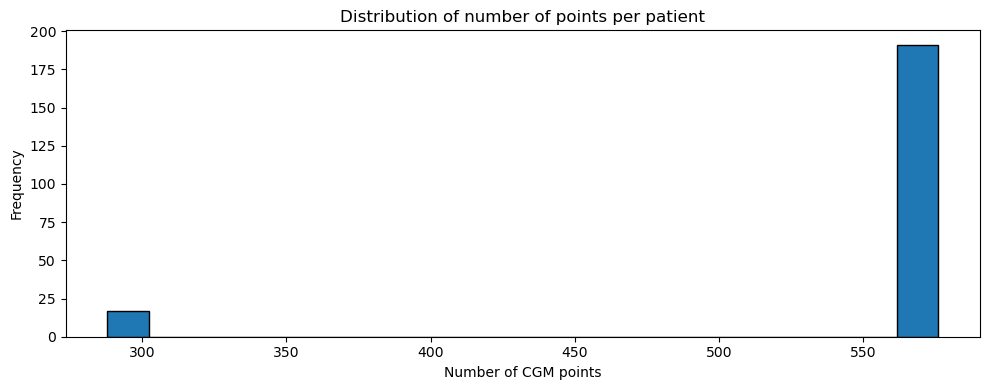

In [16]:
plt.figure(figsize=(10, 4))
plt.hist(n_points_series, bins=20, edgecolor="black")
plt.xlabel("Number of CGM points")
plt.ylabel("Frequency")
plt.title("Distribution of number of points per patient")
plt.tight_layout()
plt.show()